# LEGAL IMPRINT WAW Open Search Hackathon TUTORIAL

## Setup
 For this tutorial we use the Legal Imprint Dataset from the OpenWebSearch.eu project

The data, originally stored in parquet files, is converted into a duckdb for easier data handling.
We also use a preprocessed data sample for our geospatial analysis.


#### PYTHON SETUP
We also provide a requirements.txt with all the necessary Python packages. With that, you can create a conda/mamba environment for the tutorial:

In [ ]:
mamba create -n waw_os_legal_imprint python=3.10  # mamba/conda depending on what you use
mamba activate waw_os_legal_imprint
pip install -r requirements.txt

# in jupyter install the required packages
!pip install pandas geopandas duckdb mapclassify

## Data Source

We use the [German Imprints Dataset](https://openwebindex.eu/corpora/4057d6a0-0bd9-11f1-89ba-02a47ca5d9fd) for this tutorial. This is a large-scale collection of websites annotated with the thematic allocation of the website and the geolocation of the extracted address of the imprint website. For the extraction of the two details an LLM pipeline was used. This dataset is provided in parquet format including the URL, html information of the main page, about page and imprint page.

## Data Extraction with DuckDB
For a better data handling in this tutorial, we used [DuckDB](https://duckdb.org/) to read the parquet files and extract relevant information. Afterward, we created a duckdb file with the relevant data for this tutorial. If further data need to be extracted or prefiltered this duckdb example can help to adjust for the requirements. In this tutorial we use the pyhton DuckDB package. The integration of the DuckDB client is also an option.

Load the following libraries

In [40]:
import duckdb
import pandas as pd
import geopandas as gpd
import os
import mapclassify

In [2]:
# naviagte to the data folder
os.chdir(r"C:\Users\ritt_vn\Documents\Projects\OpenSearch@DLR2\imprint_data\WAW3_hackathon")

A DuckDB connection has to be established. It is connected to the duckdb file from the original parquet files.

In [10]:
# create the connection to the persistent database
con = duckdb.connect('data/legal_imprints_db_sample.duckdb')

# duckdb  database overview
# Query the list of tables
tables = con.execute("SHOW TABLES").fetchall()

# Print table names
for table in tables:
    print(table)

con.sql("""
SELECT * FROM imprints_all_sample LIMIT 1""")

('imprints_all_sample',)


┌──────────────┬─────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## Data Filtering examples

In [14]:
# Filter the original data
con.sql("""
CREATE TABLE imprints_with_coords AS SELECT
    host, topic, address, region,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.osm_value'))::VARCHAR as osm_value,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.type'))::VARCHAR as osm_type,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.name'))::VARCHAR as osm_name,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.osm_id'))::VARCHAR as osm_id,
    TRY(JSON_EXTRACT(coords, '$.features[0].geometry.coordinates[0]'))::DOUBLE as longitude,
    TRY(JSON_EXTRACT(coords, '$.features[0].geometry.coordinates[1]'))::DOUBLE as latitude,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.city'))::VARCHAR as osm_city,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.country'))::VARCHAR as osm_country,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.county'))::VARCHAR as osm_county,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.district'))::VARCHAR as osm_district,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.housenumber'))::VARCHAR as osm_housenumber,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.street'))::VARCHAR as osm_street,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.postcode'))::VARCHAR as osm_postcode,
    TRY(JSON_EXTRACT(coords, '$.features[0].properties.state'))::VARCHAR as osm_state
FROM imprints_all_sample
""")

CatalogException: Catalog Error: Table with name "imprints_with_coords" already exists!

In [15]:
# In this case we focus only on entries where the lat and lon and address and topic information is given
con.sql("""
CREATE TABLE imprints_final AS
SELECT *
FROM imprints_with_coords
WHERE
  latitude IS NOT NULL
  AND longitude IS NOT NULL
  AND address IS NOT NULL
  AND topic IS NOT NULL
""")

In [16]:
# We also want to extract the domains of the website to potentially use it as a filtering column
con.sql("""
CREATE TABLE imprints_with_domain AS
SELECT
  *,
  REGEXP_EXTRACT(host, '\.([a-zA-Z]{2,})$', 1) as domain
FROM imprints_final
""")

## Data Saving
1. Convert the data into a pandas dataframe for further analysis
2. Save the filtered data a csv file for further analysis in a GIS System or just for storage

In [17]:
# 1. Create pandas Dataframe
df = con.sql("SELECT * FROM imprints_with_domain").fetchdf()
print(df.head())

con.close()

# 2. Save to csv
#con.sql("COPY imprints_with_coords TO 'imprints_with_coords.csv' (HEADER, DELIMITER ',')")

                    host                            topic  \
0           www.flucc.at          Allgemeine Unterhaltung   
1           jay-knopf.eu  Möbel- und Einrichtungsgeschäft   
2             alabon.com              Unternehmensberater   
3  lilis-fellstueberl.at            Haustierpflegeservice   
4   www.muellerbbm-pm.de               Unternehmensdienst   

                                              coords  \
0  {'features': [{'geometry': {'coordinates': [16...   
1  {'features': [{'geometry': {'coordinates': [6....   
2  {'features': [{'geometry': {'coordinates': [6....   
3  {'features': [{'geometry': {'coordinates': [14...   
4  {'features': [{'geometry': {'coordinates': [11...   

                                             address  \
0  {'country': 'Österreich', 'housenumber': '5A',...   
1  {'country': 'Germany', 'housenumber': '206-206...   
2  {'country': 'Deutschland', 'housenumber': '35'...   
3  {'country': 'Austria', 'housenumber': '5A', 'p...   
4  {'country': '

##DATA statistics
Explore the dataset, what columns are there and which content is given?
What could be useful information for your research question?

## Data filtering
 In order to use the data we need to proprocess and change some data formats.

In [20]:
## Load the data as csv file
df = pd.read_csv()

In [19]:
### First: add the topic dictionary / classification to add the parent class
topic_dic = pd.read_json("data/categories_20260311_KOPIE_V2adjust.jsonl", lines=True)

In [21]:
# merge parent class to df
merged_data = pd.merge(
    df,
    topic_dic[['name', 'parent']],
    left_on='topic',
    right_on='name',
    how='left'
).drop(columns=['name'])

In [23]:
# Function to fix the dictionary output of the address in oder to be able to convert it into a dictionary
def quote_all_values_in_dict_string(s):
    """
    Converts a string representation of a dict into a real dict,
    wrapping ALL values (including numbers, booleans, None) in single quotes.

    Example:
        Input:  "{'country': Deutschland, 'housenumber': 13b, 'postalcode': 76137, 'active': True}"
        Output: {'country': 'Deutschland', 'housenumber': '13b', 'postalcode': '76137', 'active': 'True'}
    """
    if not isinstance(s, str):
        return s

    # Regex to match key: value (any value), preserving key and punctuation
    pattern = r"('([^']+)')\s*:\s*([^,\{\}$$$$]+)(?=\s*(?:,\s*'|}|$))"

    def replacer(match):
        key = match.group(1)  # e.g., "'country'"
        value = match.group(3).strip()
        # Wrap ALL values in quotes
        return f"{key}: '{value}'"

    try:
        fixed_str = re.sub(pattern, replacer, s)
        # Safely evaluate the string to a dictionary
        return ast.literal_eval(fixed_str)
    except Exception:
        # Fallback: return original string if conversion fails
        return s

# Apply to DataFrame
merged_data["address"] = merged_data["address"].apply(quote_all_values_in_dict_string)

# extract the single information

# get the address statistics and extract information as columns
merged_data['country'] = merged_data['address'].apply(lambda x: x.get('country') if isinstance(x, dict) else None)
merged_data['housenumber'] = merged_data['address'].apply(lambda x: x.get('housenumber') if isinstance(x, dict) else None)
merged_data['postalcode'] = merged_data['address'].apply(lambda x: x.get('postalcode') if isinstance(x, dict) else None)
merged_data['streetname'] = merged_data['address'].apply(lambda x: x.get('streetname') if isinstance(x, dict) else None)
merged_data['town'] = merged_data['address'].apply(lambda x: x.get('town') if isinstance(x, dict) else None)
merged_data.head()

,host,topic,address,region,osm_value,osm_type,osm_name,osm_id,longitude,latitude,...,osm_street,osm_postcode,osm_state,domain,parent,country,housenumber,postalcode,streetname,town
0,www.flucc.at,Allgemeine Unterhaltung,"{'country': 'Österreich', 'housenumber': '5A',...","{'country': 'Austria', 'county': 'Austria', 'd...","""station""","""house""","""Praterstern""",3862884758,16.393865,48.218529,...,"""Praterstern""","""1020""",null,at,Kunst und Unterhaltung,Österreich,5A,1020,Praterstern,Wien
1,jay-knopf.eu,Möbel- und Einrichtungsgeschäft,"{'country': 'Germany', 'housenumber': '206-206...","{'country': 'Germany', 'county': 'Mülheim an d...","""yes""","""house""",null,302718302,6.903032,51.452605,...,"""Mühlenstraße""","""45475""","""Nordrhein-Westfalen""",eu,Einzelhandel,Germany,206-206a,45475,Mühlenstraße,Mülheim/Ruhr
2,alabon.com,Unternehmensberater,"{'country': 'Deutschland', 'housenumber': '35'...","{'country': 'Germany', 'county': 'Städteregion...","""it""","""house""","""INFORM""",48430062,6.142540,50.714471,...,"""Pascalstraße""","""52076""","""Nordrhein-Westfalen""",com,Geschäfts- und professionelle Dienstleistungen,Deutschland,35,52076,Pascalstraße,Aachen
3,lilis-fellstueberl.at,Haustierpflegeservice,"{'country': 'Austria', 'housenumber': '5A', 'p...","{'country': 'Austria', 'county': 'Austria', 'd...","""stream""","""other""","""Hörmannser Bach""",729685489,14.968199,48.731506,...,null,null,"""Niederösterreich""",at,Geschäfts- und professionelle Dienstleistungen,Austria,5A,3961,Hörmanns,Hörmanns bei Weitra
4,www.muellerbbm-pm.de,Unternehmensdienst,"{'country': 'Deutschland', 'housenumber': '1 -...","{'country': 'Germany', 'county': 'Landkreis Mü...","""company""","""house""","""Müller-BBM Group""",8458474613,11.433705,48.107559,...,"""Helmut-A.-Müller-Straße""","""82152""","""Bayern""",de,Geschäfts- und professionelle Dienstleistungen,Deutschland,1 - 5,82152,Helmut-A.-Müller-Straße,Planegg


In [ ]:
# statistics of parent class distribution of data, domain distributions, group by region

## Geospatial Analysis

In this spatial analysis we want to spatially analyze our dataset. The locations are based on the lat/lon coordinates the Photon geocoder linked to the address extracted with the LLM pipeline. Right now the data is not spatially filtered. In order to spatially clip the data points, to be independent on the string versions of Germany, we spatially clip the points with a Vector layer of Germany.
We therefore load the BKG vector dataset of all counties in Germany.
For further spatial analysis and distribution of major classes in the county we use this dataset. This is then used to aggregate the point information on the county level and integrate the population and county size to compare the class distribution.

#### Enviornment:
We currently use Python and geospatial packages for this example analysis. If you wish, you can also export the data and use this dataset in a GIS like QGIS

In [29]:
# Load the Germany counties dataset
germany_counties = gpd.read_file('data/VG250_KRS.shp')

In [26]:
# export points as csv file

# OR
# convert data into a geodataframe and save it as a geojson
# Our data conatins latitude and longitude data we first load the geodataframe with EPSG 4326 (WGS84) coordinate system
# For further analysis and comparison the data then can for example be reprjected to the same UTM Coordinate system like the administrative data of Germany.
imprint = gpd.GeoDataFrame(merged_data, geometry=gpd.points_from_xy(merged_data.longitude, merged_data.latitude), crs="EPSG:4326")

# adjust projection
imprint = imprint.to_crs(germany_counties.crs)

# test the projection, it should be EPSG:25832
print(imprint.crs)

# Clip points to Germany
imprint_ger = gpd.clip(imprint, germany_counties)

EPSG:25832


<Axes: >

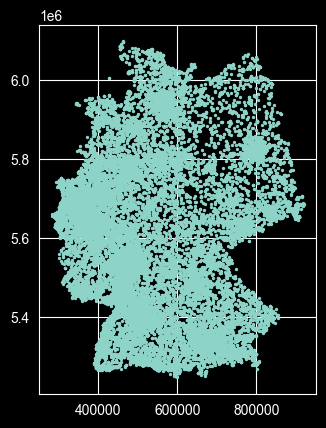

In [28]:
# Viszualize the points
imprint_ger.plot(markersize=2)

In [34]:
# Count points in poyldon to get the number of polygons in each county
spatial_join = gpd.sjoin(imprint_ger, germany_counties, how='left', predicate='within')
#print(spatial_join.head())
point_counts = spatial_join.groupby('index_right').size().rename('point_count')
counties_gdf = germany_counties.merge(
    point_counts,
    left_index=True,
    right_index=True,
    how='left'
)
print(counties_gdf.head())

              OBJID     BEGINN  ADE  GF  BSG    ARS    AGS       SDV_ARS  \
0  DEBKGVG200000C75 2021-12-02    4   4    1  01001  01001  010010000000   
1  DEBKGVG200000C76 2021-11-30    4   4    1  01002  01002  010020000000   
2  DEBKGVG200000C77 2021-06-24    4   4    1  01003  01003  010030000000   
3  DEBKGVG200000C78 2021-08-24    4   4    1  01004  01004  010040000000   
4  DEBKGVG200000C79 2021-11-17    4   4    1  01051  01051  010510044044   

            GEN               BEZ  ...  FK_S3   NUTS         ARS_0     AGS_0  \
0     Flensburg  Kreisfreie Stadt  ...      R  DEF01  010010000000  01001000   
1          Kiel  Kreisfreie Stadt  ...      R  DEF02  010020000000  01002000   
2        Lübeck  Kreisfreie Stadt  ...      R  DEF03  010030000000  01003000   
3    Neumünster  Kreisfreie Stadt  ...      R  DEF04  010040000000  01004000   
4  Dithmarschen             Kreis  ...      R  DEF05  010510000000  01051000   

         WSK     EWZ      KFL            DLM_ID  \
0 2008-01-0

<Axes: >

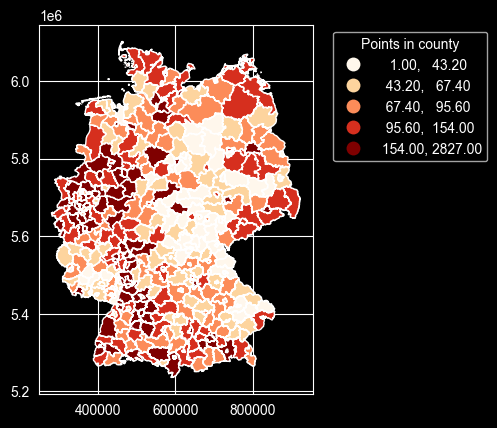

In [46]:
# Vizualize
counties_gdf.plot(column='point_count',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Points in county", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [51]:
# count points in polygon by major class -> Vizusalize major topic class per county
spatial_join = gpd.sjoin(imprint_ger, germany_counties, how='left', predicate='within')
grouped = spatial_join.groupby(['index_right', 'parent']).size().rename('point_count').unstack(fill_value=0)
counties_gdf = germany_counties.merge(
    grouped,
    left_index=True,
    right_index=True,
    how='left'
)
print(counties_gdf.head())

              OBJID     BEGINN  ADE  GF  BSG    ARS    AGS       SDV_ARS  \
0  DEBKGVG200000C75 2021-12-02    4   4    1  01001  01001  010010000000   
1  DEBKGVG200000C76 2021-11-30    4   4    1  01002  01002  010020000000   
2  DEBKGVG200000C77 2021-06-24    4   4    1  01003  01003  010030000000   
3  DEBKGVG200000C78 2021-08-24    4   4    1  01004  01004  010040000000   
4  DEBKGVG200000C79 2021-11-17    4   4    1  01051  01051  010510044044   

            GEN               BEZ  ...  Finanzdienstleistung  \
0     Flensburg  Kreisfreie Stadt  ...                   0.0   
1          Kiel  Kreisfreie Stadt  ...                   1.0   
2        Lübeck  Kreisfreie Stadt  ...                   1.0   
3    Neumünster  Kreisfreie Stadt  ...                   1.0   
4  Dithmarschen             Kreis  ...                   0.0   

  Gemeinschaft und Regierung Geschäfts- und professionelle Dienstleistungen  \
0                        9.0                                           21.0   


<Axes: >

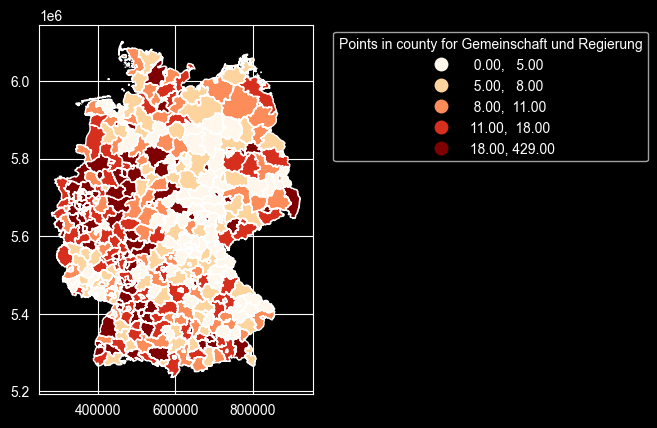

In [52]:
# Vizualize a specific class
counties_gdf.plot(column='Gemeinschaft und Regierung',
                  cmap='OrRd',
                  scheme='quantiles',
                  legend=True,
                  legend_kwds={"title": "Points in county for Gemeinschaft und Regierung", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [55]:
# Find the max class of the classes per county
counties_gdf['max_class'] = grouped.idxmax(axis=1)

# Find the actual maximum count value
counties_gdf['max_val'] = grouped.max(axis=1)
# if nothing has been found:
counties_gdf['max_class'] = counties_gdf['max_class'].fillna('No Points')
counties_gdf['max_val'] = counties_gdf['max_val'].fillna(0).astype(int)

<Axes: >

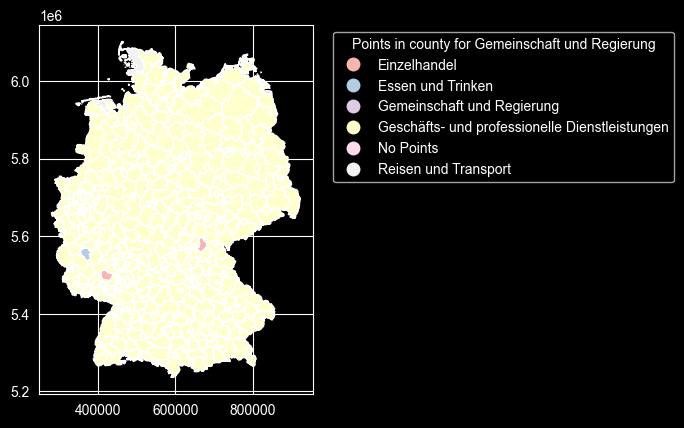

In [57]:
# Vizualize a specific class
counties_gdf.plot(column='max_class',
                  cmap='Pastel1',
                  legend=True,
                  legend_kwds={"title": "Points in county for Gemeinschaft und Regierung", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

In [ ]:
# vizualize data per bivariate map by population entries in state or km2 size

<Axes: >

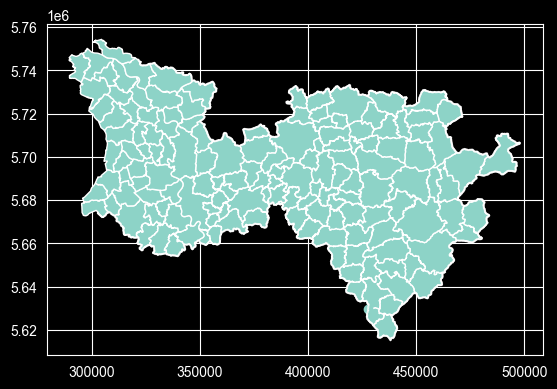

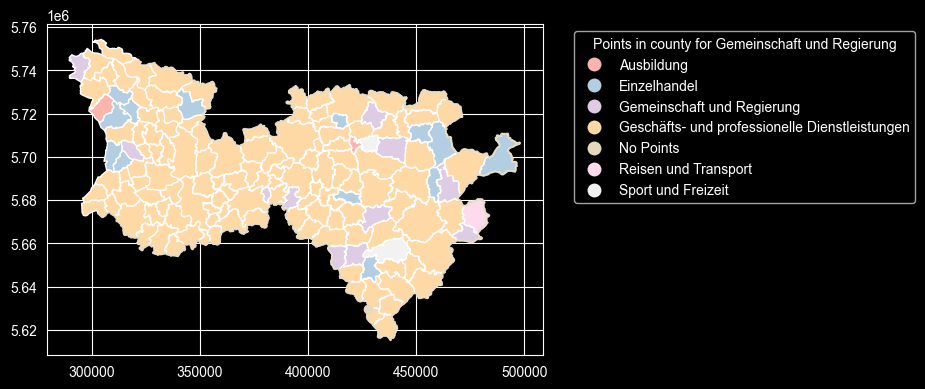

In [61]:
## Example on a spatially smaller level

# Load the municiplaities for the Ruhrgebiet
munici = gpd.read_file(r"C:\Users\ritt_vn\Documents\Projects\OpenSearch@DLR2\Admin_data_Ahrtal\vg250-ew_12-31.utm32s.shape.ebenen\vg250-ew_ebenen_1231\VG250_GEM.shp")

# load the Regierungsbezirk and filter for two
rbz = gpd.read_file(r"C:\Users\ritt_vn\Documents\Projects\OpenSearch@DLR2\Admin_data_Ahrtal\vg250-ew_12-31.utm32s.shape.ebenen\vg250-ew_ebenen_1231\VG250_RBZ.shp")

# filter
rbz_sel = rbz[(rbz['GEN'] == 'Arnsberg') | (rbz['GEN'] == 'Düsseldorf')]

# clip municiplaities with the regierungsbezir area
munici_clip = gpd.clip(munici, rbz_sel)

munici_clip.plot()

# count points in the counties
spatial_join = gpd.sjoin(imprint_ger, munici_clip, how='left', predicate='within')
grouped = spatial_join.groupby(['index_right', 'parent']).size().rename('point_count').unstack(fill_value=0)
counties_gdf_sel = munici_clip.merge(
    grouped,
    left_index=True,
    right_index=True,
    how='left'
)
# Find the actual maximum count value
counties_gdf_sel['max_class'] = grouped.idxmax(axis=1)
counties_gdf_sel['max_val'] = grouped.max(axis=1)
# if nothing has been found:
counties_gdf_sel['max_class'] = counties_gdf_sel['max_class'].fillna('No Points')
counties_gdf_sel['max_val'] = counties_gdf_sel['max_val'].fillna(0).astype(int)

# Vizualize a specific class
counties_gdf_sel.plot(column='max_class',
                  cmap='Pastel1',
                  legend=True,
                  legend_kwds={"title": "Points in county for Gemeinschaft und Regierung", "bbox_to_anchor": (1.05, 1), "loc": "upper left" })

## DIY

Not it is your turn. Play around with certain filtering parameters, filtering for specific areas and topics and use the data for your scientific research question. You can also integrate your own (geospatial) data and synergistically analyze the data products.